## USE CASES 
        OF BTG IT Sessions 2026 - Módulo 13: Inteligência Artificial



##### MODULE 1: CLASSIFICATION

-------------------------------------------------------------------------------------

##### SCIKIT-LEARN WEBSITE

[https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)

--------------------------------------------------------------------------------------------------------


In [23]:
# Installing required libraries

import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [24]:
# reading the CSV file into a DataFrame
dataset = pd.read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/modeldata/credit_data.csv")

In [25]:
# Verifying the first few rows of the dataset
print(dataset.head())

   rownames Status  Seniority   Home  Time  Age  Marital Records        Job  \
0         1   good          9   rent    60   30  married      no  freelance   
1         2   good         17   rent    60   58    widow      no      fixed   
2         3    bad         10  owner    36   46  married     yes  freelance   
3         4   good          0   rent    60   24   single      no      fixed   
4         5   good          0   rent    36   26   single      no      fixed   

   Expenses  Income  Assets  Debt  Amount  Price  
0        73   129.0     0.0   0.0     800    846  
1        48   131.0     0.0   0.0    1000   1658  
2        90   200.0  3000.0   0.0    2000   2985  
3        63   182.0  2500.0   0.0     900   1325  
4        46   107.0     0.0   0.0     310    910  


In [26]:
# Verifying null values in the dataset, those columns with null values will be displayed with their respective counts
# print(dataset.isnull().sum())

In [27]:
# Making data validation with ISNA:
# isna contains the same information as isnull, but isna is more intuitive to read and understand. 
# null values that can include noise to algorithms and models, so it is important to identify and handle them appropriately. 
# print(dataset.isna().sum())
dataset.isna().sum()

rownames       0
Status         0
Seniority      0
Home           6
Time           0
Age            0
Marital        1
Records        0
Job            2
Expenses       0
Income       381
Assets        47
Debt          18
Amount         0
Price          0
dtype: int64

In [28]:
# substitute numeric values that are null with the median of the column,
# dataset = dataset.fillna(dataset.median(), inplace=True)

# the above instrunction cause error 
#   --> TypeError: Cannot perform reduction 'median' with string dtype

# In order of to avoid the error, we need to separate the numeric columns from the categorical columns and then apply the median function only to the numeric columns.


In [29]:
# Selecionar apenas colunas numéricas
# A mediana só pode ser calculada em colunas com valores numéricos.
# AS duas formas abaixo funcionam

# dataset_numeric2 = dataset.select_dtypes(include=['float64', 'int64'])
dataset_numeric = dataset.select_dtypes(include=['number'])

In [30]:
# Calcular a mediana das colunas numéricas
# Agora você pode calcular a mediana sem erro.

median_values = dataset_numeric.median()

In [31]:
#Substituir valores nulos pelas medianas
# Preencha os valores nulos apenas nas colunas numéricas.

# dataset[dataset_numeric.columns] = dataset_numeric.columns.fillna(median_values)
dataset[dataset_numeric.columns] = dataset_numeric.fillna(median_values)

In [32]:
dataset.isna().sum()

rownames     0
Status       0
Seniority    0
Home         6
Time         0
Age          0
Marital      1
Records      0
Job          2
Expenses     0
Income       0
Assets       0
Debt         0
Amount       0
Price        0
dtype: int64

In [33]:
dataset.head(5)

,rownames,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,good,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,2,good,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,3,bad,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,4,good,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,5,good,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910


In [34]:
# substitute categorical values that are null with the mode of the column,

# dataset_normalized = dataset.fillna(dataset.mode().iloc[0])
dataset = dataset.fillna(dataset.mode())

In [35]:
dataset.head(5)

,rownames,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,good,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,2,good,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,3,bad,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,4,good,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,5,good,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910


In [36]:
# Removing lines with null values from the dataset

# axis=1 --> column
# axis=0 --> line
# ---------------------------

try:
    dataset_normalized = dataset.drop('Unnamed: 0', axis=1)
except Exception as e:
    print(f"Error occurred while dropping column: {e}")
    dataset_normalized = dataset.dropna()
finally:
    print("Column dropped successfully or dataset cleaned.")
    features = dataset_normalized.drop('Status', axis=1)
    

Error occurred while dropping column: "['Unnamed: 0'] not found in axis"
Column dropped successfully or dataset cleaned.


In [37]:
# performe Label encoding to convert categorical variables into numerical format, which is necessary for many machine learning algorithms.

label_encoder = LabelEncoder()
encoded = label_encoder.fit_transform(dataset_normalized['Status'])
credit_aprove = pd.DataFrame(encoded, columns=['Status'])

In [38]:
# features.columns

In [39]:
credit_aprove.head(5)

,Status
0,1
1,1
2,0
3,1
4,1


In [40]:
categorical_columns = features.select_dtypes(include=['str']).columns
# categorical_columns = dataset_normalized.select_dtypes(include=['str']).columns

In [41]:
for col in categorical_columns:
    features[col] = label_encoder.fit_transform(features[col])

In [42]:
features.head(5)

,rownames,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,5,60,30,1,0,1,73,129.0,0.0,0.0,800,846
1,2,17,5,60,58,4,0,0,48,131.0,0.0,0.0,1000,1658
2,3,10,2,36,46,1,1,1,90,200.0,3000.0,0.0,2000,2985
3,4,0,5,60,24,3,0,0,63,182.0,2500.0,0.0,900,1325
4,5,0,5,36,26,3,0,0,46,107.0,0.0,0.0,310,910


In [43]:
# Formatting the dataset to be used in the machine learning model

X = features.iloc[:, :-1].values

Y = credit_aprove.iloc[:, -1].values

##### TRAIN AND TEST MODEL LogisticRegression

In [44]:
''' Preparing the model for training and testing
 MODEL: logistic regression, which is a statistical method for analyzing datasets in which there are one or more independent variables that determine an outcome. The outcome is measured with a dichotomous variable (in which there are only two possible outcomes).
'''

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


lr = LogisticRegression(max_iter=100, solver="liblinear") 

# Definindo o número de folds para validação cruzada
kf = KFold(n_splits=10)

# Training the model using cross-validation and calculating the accuracy scores
scores = cross_val_score(lr, X, Y, cv=kf, scoring='accuracy')


##### RESULT OF ML MODEL LogisticRegression

In [45]:
# Show the accuracy scores for each fold in a more readable format

# Mean accuracy of the model across all folds
print("Mean accuracy: {:.3f}".format(scores.mean()))

# Accuracy scores for each fold
print("Accuracy scores for each fold: \n ", scores)

# Standard deviation of the accuracy scores 
print("Standard deviation of accuracy scores: ", round((scores.std() * 2), 3))  # multiplied by 2 for a 95% confidence interval  


Mean accuracy: 0.781
Accuracy scores for each fold: 
  [0.81797753 0.7505618  0.76179775 0.76179775 0.78876404 0.81348315
 0.77927928 0.78828829 0.79279279 0.75900901]
Standard deviation of accuracy scores:  0.044


##### VIEW CONFUSION MATRIX FOR LogisticRegression Model

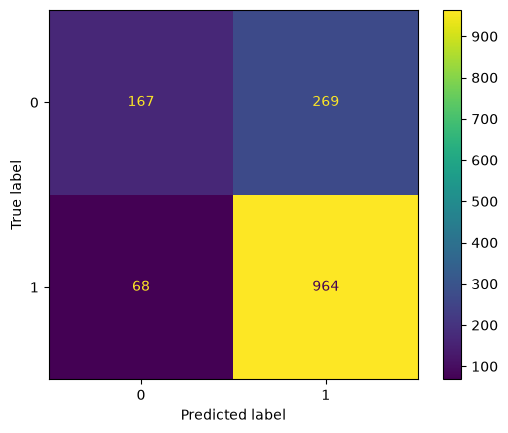

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

lr.fit(x_train, y_train)
y_predict = lr.predict(x_test)

conf_matrix = confusion_matrix(y_test, y_predict)

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, display_labels=lr.classes_)


disp.plot(cmap='viridis')
plt.show()

##### TRAIN AND TEST MODEL RandomForestClassifier

In [47]:
# Preparing the model for training and testing
# MODEL: Randomforest 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier() 

# Definindo o número de folds para validação cruzada
kf = KFold(n_splits=10)

# Training the model using cross-validation and calculating the accuracy scores
rf_scores = cross_val_score(rf, X, Y, cv=kf, scoring='accuracy')


##### RESULT OF MODEL  RandomForestClassifier

In [48]:
# Show the accuracy scores for each fold in a more readable format

# Mean accuracy of the model across all folds
print("RandomForest Mean accuracy: {:.3f}".format(rf_scores.mean()))

# Accuracy scores for each fold
# print("Accuracy scores for each fold: \n ", rf_scores)

# Standard deviation of the accuracy scores 
print("RandomForest Standard deviation of accuracy scores: ", round((rf_scores.std() * 2), 3)) 


RandomForest Mean accuracy: 0.785
RandomForest Standard deviation of accuracy scores:  0.04


##### VIEW CONFUSION MATRIX FOR RandomForestClassifier Model

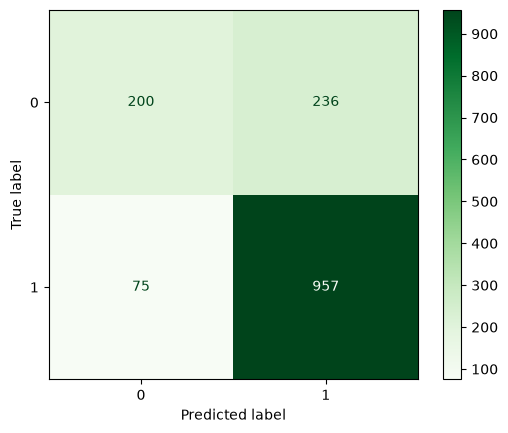

In [49]:

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

rf.fit(x_train, y_train)
y_predict = rf.predict(x_test)

conf_matrix = confusion_matrix(y_test, y_predict)

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, display_labels=rf.classes_)


disp.plot(cmap='Greens')
plt.show()

##### TRAIN AND TEST MODEL GradientBoostingClassifier

In [50]:
# Preparing the model for training and testing
# MODEL: Gradient Boosting Classifier 

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier() 

# Definindo o número de folds para validação cruzada
kf = KFold(n_splits=10)

# Training the model using cross-validation and calculating the accuracy scores
gb_scores = cross_val_score(gb, X, Y, cv=kf, scoring='accuracy')


# -----------------------------------------------------------------------
# results of the Gradient Boosting Classifier will be displayed below
# -----------------------------------------------------------------------

print("GradientBoosting Mean accuracy: {:.3f}".format(gb_scores.mean()))

# Standard deviation of the accuracy scores 
print("GradientBoosting Standard deviation of accuracy scores: ", round((gb_scores.std() * 2), 3)) 


GradientBoosting Mean accuracy: 0.796
GradientBoosting Standard deviation of accuracy scores:  0.053


##### VIEW CONFUSION MATRIX FOR GradientBoostingClassifier Model

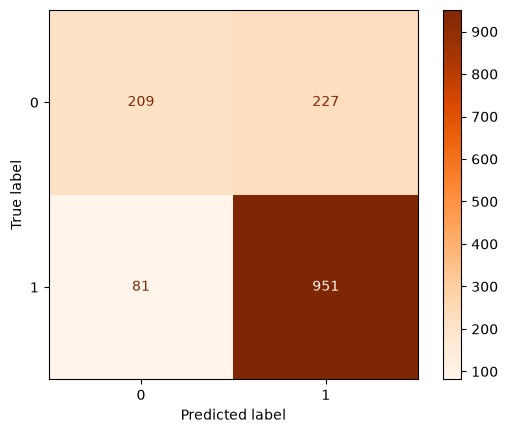

In [51]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

gb.fit(x_train, y_train)
y_predict = gb.predict(x_test)

conf_matrix = confusion_matrix(y_test, y_predict)

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, display_labels=gb.classes_)


disp.plot(cmap='Oranges')
plt.show()